In [1]:
import subprocess
import numpy as np
import pandas as pd

In [ ]:


def process_sample(path, MAPQ_cutoff=55, max_len=400):

    # 1. histogram counts + overflow bin
    counts = np.zeros(max_len + 1, dtype=int)

    # 2. # fragments in raw data + after MAPQ filtering
    total_raw = 0
    total_filtered = 0

    # 3. open gzipped file met subprocess
    proc = subprocess.Popen(
        ["bgzip", "-cd", path],
        stdout=subprocess.PIPE,
        text=True
    )

    # 4. iterate through lines in file
    for line in proc.stdout:

        total_raw += 1

        chr_name, start, end, mapQ, strand = line.rstrip().split("\t")

        mapQ = int(mapQ)

        # 5. MAPQ filter
        if mapQ < MAPQ_cutoff:
            continue

        total_filtered += 1

        # 6. fragment length berekenen
        start = int(start)
        end = int(end)
        length = end - start

        # 7. binning + overflow handling
        if length >= max_len:
            counts[max_len] += 1
        else:
            counts[length] += 1

    # 8. normalize by total filtered fragments
    series = pd.Series(
        counts,
        index=list(range(max_len)) + ["400+"]
    )

    series = series / total_filtered

    # 9. return both signal + QC
    return series, total_filtered, total_raw

In [30]:
s1, s1_filtered, s1_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85723.hg38.frag.tsv.bgz")
s2, s2_filtered, s2_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85724.hg38.frag.tsv.bgz")
s3, s3_filtered, s3_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85725.hg38.frag.tsv.bgz")
s4, s4_filtered, s4_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85726.hg38.frag.tsv.bgz")
s5, s5_filtered, s5_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85727.hg38.frag.tsv.bgz")
s6, s6_filtered, s6_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85728.hg38.frag.tsv.bgz")   
s7, s7_filtered, s7_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85729.hg38.frag.tsv.bgz")   
s8, s8_filtered, s8_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85730.hg38.frag.tsv.bgz")
s9, s9_filtered, s9_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85734.hg38.frag.tsv.bgz")   
s10, s10_filtered, s10_raw = process_sample("/Users/mariekevandeven/stage_fragmentomics/data/EE85735.hg38.frag.tsv.bgz")


In [31]:
df = pd.DataFrame({
    "EE85723": s1,
    "EE85726": s2,
    "EE85728": s3,
    "EE85724": s4,
    "EE85725": s5,
    "EE85727": s6,
    "EE85729": s7,
    "EE85730": s8,
    "EE85734": s9,
    "EE85735": s10
})

df = df.T

<Axes: >

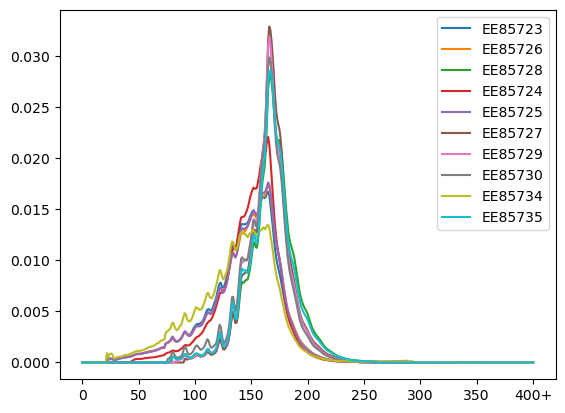

In [32]:
df.T.plot()

In [33]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,391,392,393,394,395,396,397,398,399,400+
EE85723,0.0,0.0,3.810895e-07,5.081194e-07,6.351492e-07,5.081194e-07,6.351492e-07,3.810895e-07,2.540597e-07,7.621790e-07,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EE85726,0.0,0.0,5.338673e-07,3.559116e-07,1.779558e-07,9.787568e-07,3.559116e-07,8.897789e-08,8.897789e-07,1.245690e-06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EE85728,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EE85724,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
EE85725,0.0,0.0,4.353117e-07,2.902078e-07,2.902078e-07,1.451039e-07,1.451039e-07,1.015727e-06,7.255195e-07,1.015727e-06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
qc_df = pd.DataFrame([
    {"sample": "EE85723", "raw": s1_raw, "filtered": s1_filtered},
    {"sample": "EE85726", "raw": s2_raw, "filtered": s2_filtered},
    {"sample": "EE85728", "raw": s3_raw, "filtered": s3_filtered},
    {"sample": "EE85724", "raw": s4_raw, "filtered": s4_filtered},
    {"sample": "EE85725", "raw": s5_raw, "filtered": s5_filtered},
    {"sample": "EE85727", "raw": s6_raw, "filtered": s6_filtered},
    {"sample": "EE85729", "raw": s7_raw, "filtered": s7_filtered},
    {"sample": "EE85730", "raw": s8_raw, "filtered": s8_filtered},
    {"sample": "EE85734", "raw": s9_raw, "filtered": s9_filtered},
    {"sample": "EE85735", "raw": s10_raw, "filtered": s10_filtered}
])


In [35]:
qc_df["ratio"] = qc_df["filtered"] / qc_df["raw"]

In [36]:
print(qc_df)

    sample       raw  filtered     ratio
0  EE85723  28836895   7872166  0.272989
1  EE85726  38713830  11238747  0.290303
2  EE85728  22262238  18987500  0.852902
3  EE85724  37892875  13017336  0.343530
4  EE85725  24676791   6891614  0.279275
5  EE85727  25748217  21852109  0.848684
6  EE85729  17749628  15082110  0.849714
7  EE85730  25279646  21440479  0.848132
8  EE85734  14620140   3337724  0.228296
9  EE85735  21802792  18513133  0.849118
